# Paper plots
Questo notebook genera i plot richiesti dal paper usando i CSV in `../results/`.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RECORDS = '../results/records.csv'
LRA = '../results/lra_records.csv'
EFF = '../results/efficiency.csv'


In [27]:
# Utils

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def to_numeric(df):
    return df.apply(pd.to_numeric, errors='coerce')


def kmer_metric_cols(df, metric, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_' + metric)]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_' + metric)]
    return cols


def fm_metric_cols(df, metric):
    return [c for c in df.columns if c.startswith('fm_') and c.endswith('_' + metric)]


def best_kmer(df, metric, include_multi=True):
    cols = kmer_metric_cols(df, metric, include_multi=include_multi)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_kmer_{metric}'
    return out


def best_fm(df, metric):
    cols = fm_metric_cols(df, metric)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_fm_{metric}'
    return out


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


## 1) Per ogni FM: best k-mer (y) vs performance FM (x)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


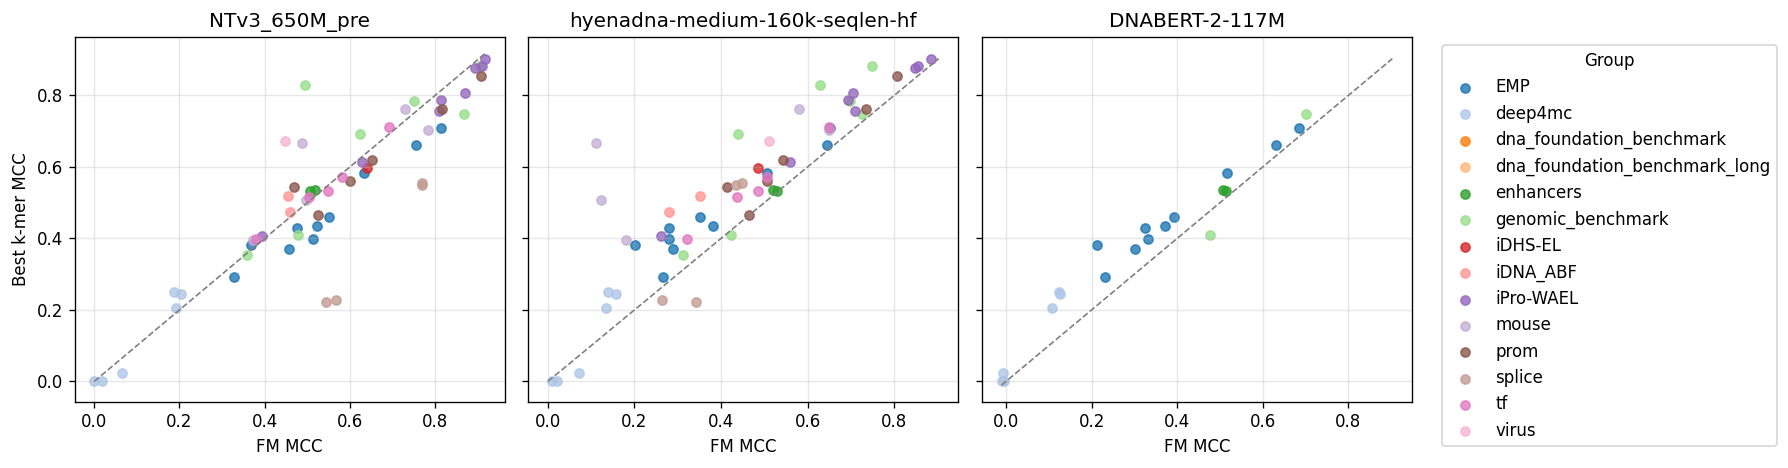

In [28]:
metric = 'MCC'  # cambia in AUROC/F1/Accuracy se serve

df = load_records()
cols_fm = fm_metric_cols(df, metric)
palette = dataset_palette(df)

best_k = best_kmer(df, metric)

n = len(cols_fm)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols_fm):
    x = pd.to_numeric(df[col], errors='coerce')
    y = best_k
    for g, sub in df.groupby('group'):
        ax.scatter(x.loc[sub.index], y.loc[sub.index], label=g, alpha=0.8, s=30, color=palette[g])
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)
    ax.set_title(col.replace('fm_', '').replace('_' + metric, ''))
    ax.set_xlabel(f'FM {metric}')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(f'Best k-mer {metric}')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group')
plt.tight_layout()


## 2) Performance task di regressione


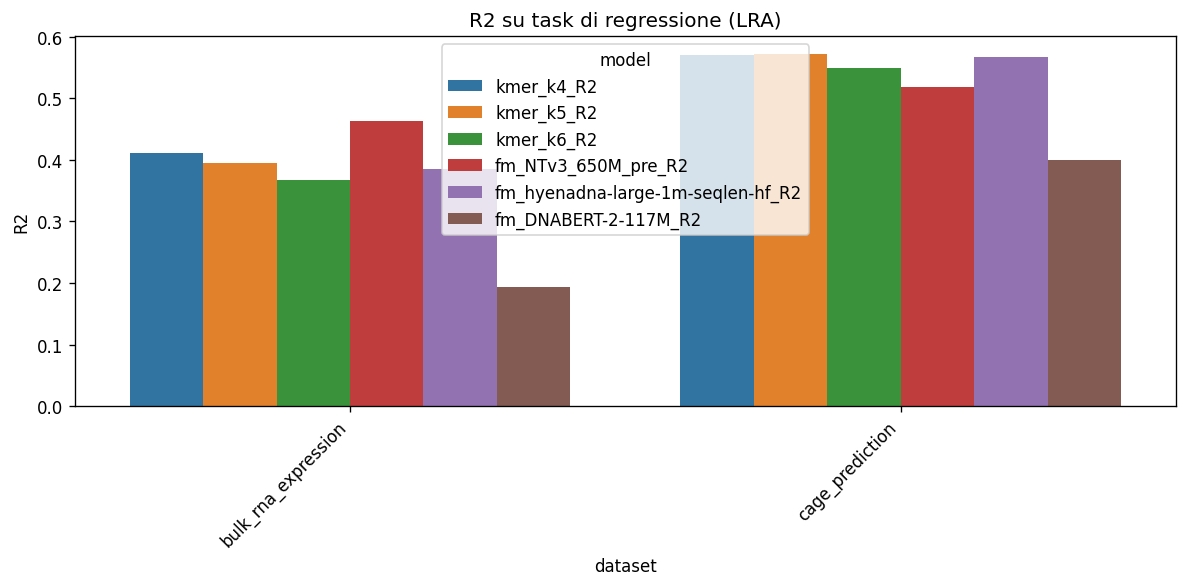

In [29]:
# LRA regression tasks
lra = pd.read_csv(LRA)

# righe con R2 disponibili
reg = lra[lra['kmer_k4_R2'].notna()].copy()

# seleziona modelli e prepara long format
r2_cols = [c for c in reg.columns if c.endswith('_R2')]
reg_long = reg.melt(id_vars=['dataset'], value_vars=r2_cols, var_name='model', value_name='R2')
reg_long['R2'] = pd.to_numeric(reg_long['R2'], errors='coerce')
reg_long = reg_long.dropna()

plt.figure(figsize=(10, 5))
sns.barplot(data=reg_long, x='dataset', y='R2', hue='model')
plt.xticks(rotation=45, ha='right')
plt.title('R2 su task di regressione (LRA)')
plt.tight_layout()


## 3) Vantaggio FM vs complessita (lunghezza sequenza)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


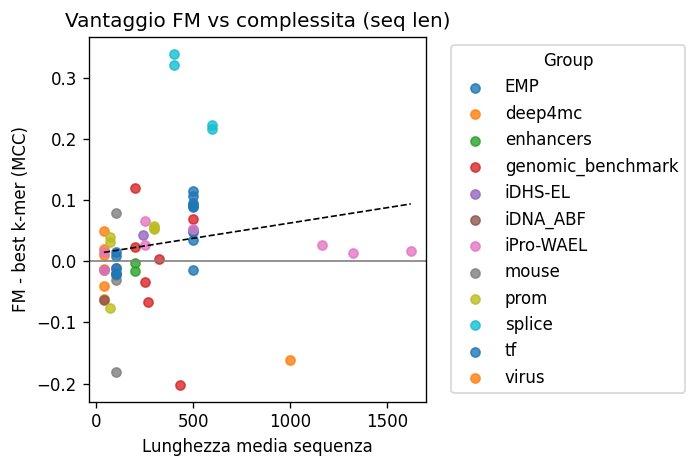

In [30]:
metric = 'MCC'

df = load_records()

best_k = best_kmer(df, metric)
best_f = best_fm(df, metric)

plot_df = df[['seq_len_mean', 'group']].copy()
plot_df['delta_fm_kmer'] = best_f - best_k
plot_df['seq_len_mean'] = pd.to_numeric(plot_df['seq_len_mean'], errors='coerce')

plt.figure(figsize=(6, 4))
for g, sub in plot_df.dropna().groupby('group'):
    plt.scatter(sub['seq_len_mean'], sub['delta_fm_kmer'], alpha=0.8, s=30, label=g)

# retta di tendenza
x = plot_df['seq_len_mean']
y = plot_df['delta_fm_kmer']
mask = x.notna() & y.notna()
if mask.sum() > 2:
    m, b = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 100)
    plt.plot(xs, m*xs + b, c='black', lw=1, ls='--')

plt.axhline(0, c='gray', lw=1)
plt.xlabel('Lunghezza media sequenza')
plt.ylabel(f'FM - best k-mer ({metric})')
plt.title('Vantaggio FM vs complessita (seq len)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group')
plt.tight_layout()


## 4) Efficienza: k-mer vs FM


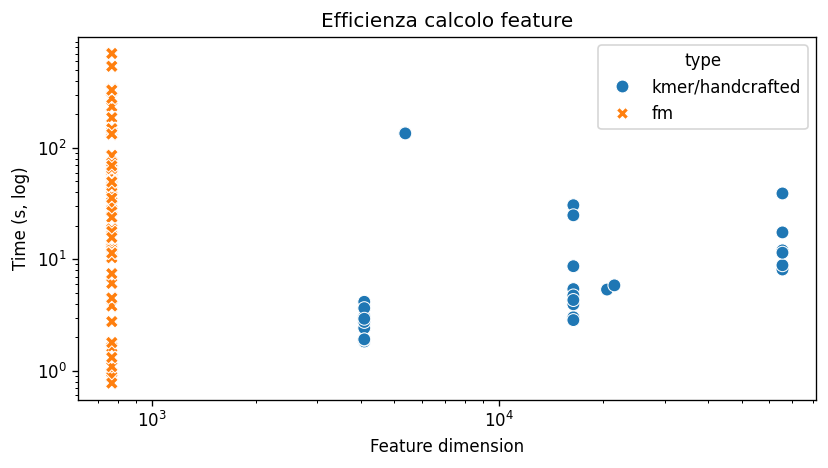

In [31]:
# Efficiency plot

eff = pd.read_csv(EFF)

# se disponibile, aggiungi una colonna tipo per colorare

def method_type(m):
    m = m.lower()
    if m.startswith('kmer') or 'kmer' in m or m.startswith('wms') or m.startswith('qt') or m.startswith('wavelet'):
        return 'kmer/handcrafted'
    if m.startswith('fm_') or m.startswith('tok_'):
        return 'fm'
    return 'other'

eff['type'] = eff['method'].map(method_type)

plt.figure(figsize=(7, 4))
sns.scatterplot(data=eff, x='feat_dim', y='time_sec', hue='type', style='type', s=60)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Feature dimension')
plt.ylabel('Time (s, log)')
plt.title('Efficienza calcolo feature')
plt.tight_layout()


## 5) Regressione lineare: k-mer spiega embeddings FM (R2)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


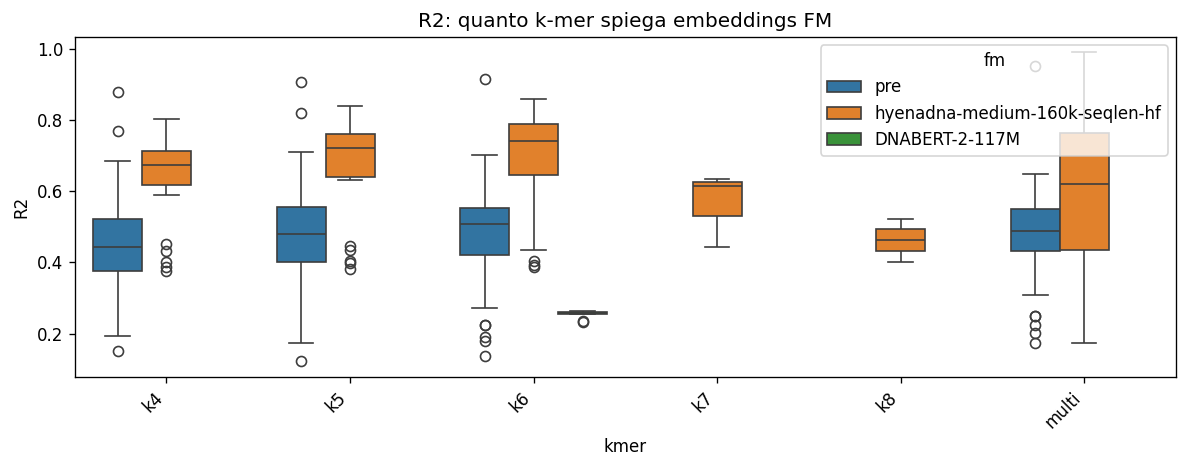

In [32]:
# Usa le colonne ridge_k*_FM_R2 in records.csv

df = load_records()

ridge_cols = [c for c in df.columns if c.startswith('ridge_') and c.endswith('_R2')]

ridge = df[ridge_cols].apply(pd.to_numeric, errors='coerce')

# long format: dataset, feature, model
long = ridge.reset_index().melt(id_vars=['dataset'], var_name='feat_model', value_name='R2')

# parse k e FM dal nome colonna
# esempi: ridge_k4_NTv3_650M_pre_R2, ridge_multi_k4_5_6_hyenadna-medium-160k-seqlen-hf_R2

long['kmer'] = long['feat_model'].str.extract(r'ridge_(.+?)_')
long['fm'] = long['feat_model'].str.extract(r'_([^_]+)_R2$')

# pulizia
long = long.dropna()

# plot: R2 vs k-mer per ciascun FM
plt.figure(figsize=(10, 4))
sns.boxplot(data=long, x='kmer', y='R2', hue='fm')
plt.xticks(rotation=45, ha='right')
plt.title('R2: quanto k-mer spiega embeddings FM')
plt.tight_layout()


## 6) Heatmap performance (ranking per dataset)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


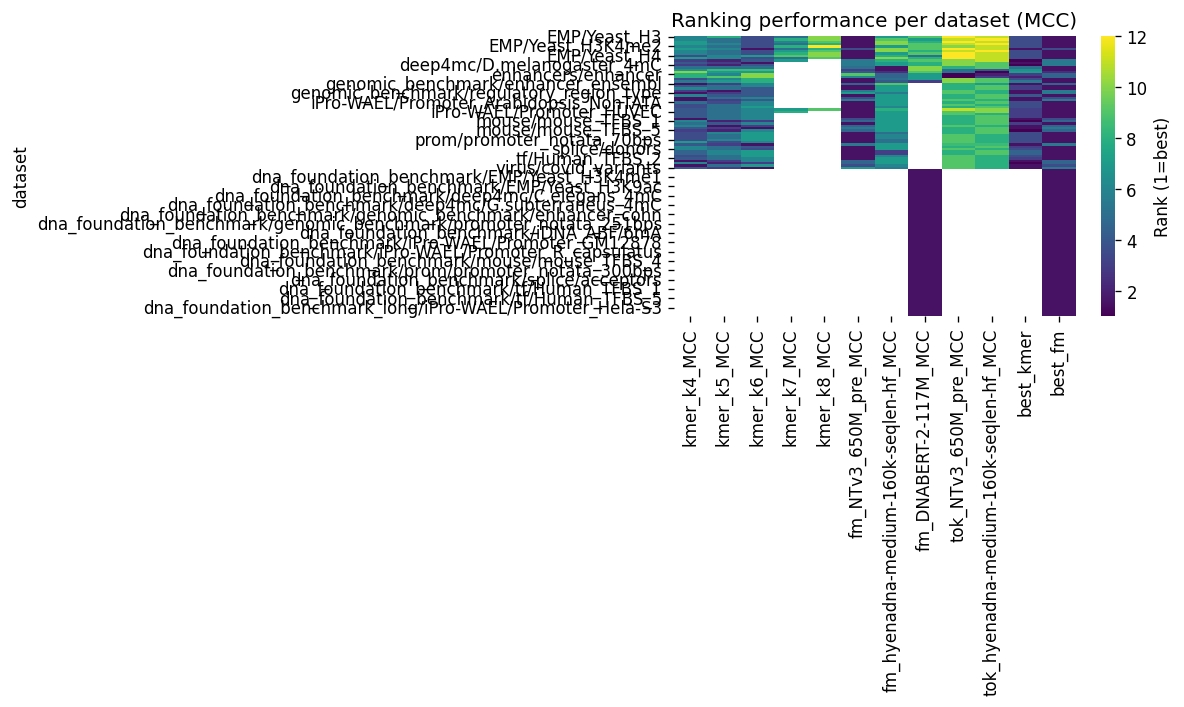

In [33]:
metric = 'MCC'

df = load_records()

# colonne candidate
cand = [
    'kmer_k4_MCC', 'kmer_k5_MCC', 'kmer_k6_MCC', 'kmer_k7_MCC', 'kmer_k8_MCC',
    'fm_NTv3_650M_pre_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC', 'fm_DNABERT-2-117M_MCC',
    'tok_NTv3_650M_pre_MCC', 'tok_hyenadna-medium-160k-seqlen-hf_MCC',
]

# aggiungi best kmer e best fm
best_k = best_kmer(df, metric)
best_f = best_fm(df, metric)

heat = df[[c for c in cand if c in df.columns]].apply(pd.to_numeric, errors='coerce')
heat['best_kmer'] = best_k
heat['best_fm'] = best_f

# rank per riga (1 = migliore)
rank = heat.rank(axis=1, ascending=False, method='average')

plt.figure(figsize=(10, 6))
sns.heatmap(rank, cmap='viridis', cbar_kws={'label': 'Rank (1=best)'})
plt.title('Ranking performance per dataset (MCC)')
plt.tight_layout()


## 7) Sensibilita a k (k-mer)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


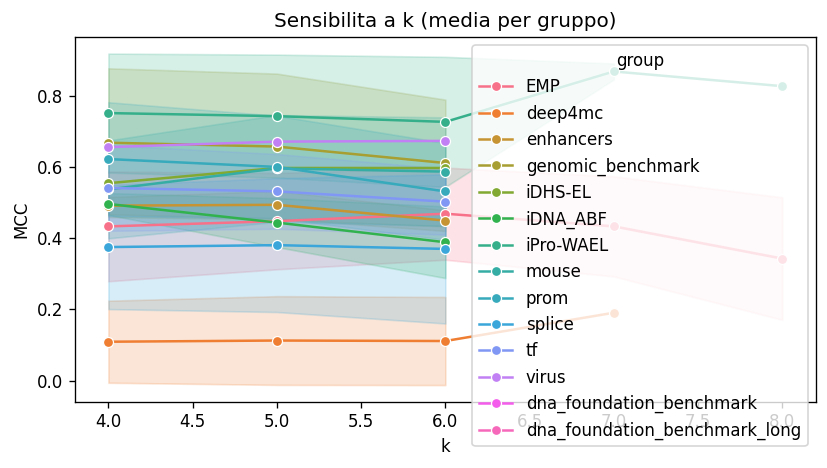

In [34]:
metric = 'MCC'

df = load_records()

k_cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_' + metric)]

# long format con k
long = df[k_cols].apply(pd.to_numeric, errors='coerce')
long['group'] = df['group']
long = long.reset_index().melt(id_vars=['dataset', 'group'], var_name='k', value_name=metric)
long['k'] = long['k'].str.extract(r'kmer_k(\d+)').astype(float)

plt.figure(figsize=(7, 4))
sns.lineplot(data=long, x='k', y=metric, hue='group', marker='o', errorbar='sd')
plt.title('Sensibilita a k (media per gruppo)')
plt.tight_layout()


## 8) Vantaggio FM vs dimensione dataset (n_train)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


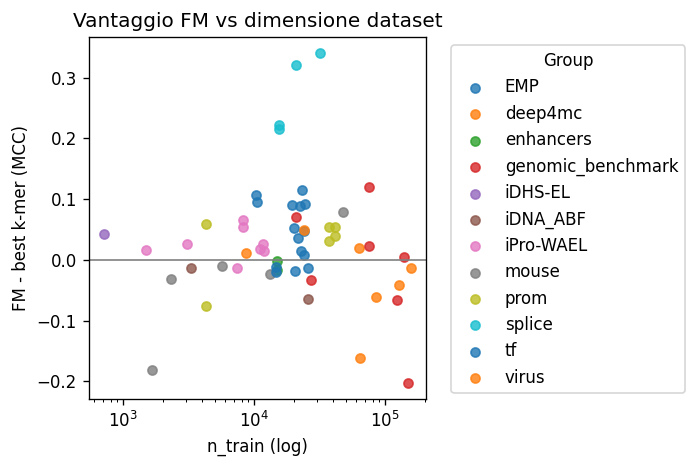

In [35]:
metric = 'MCC'

df = load_records()

best_k = best_kmer(df, metric)
best_f = best_fm(df, metric)

plot_df = df[['n_train', 'group']].copy()
plot_df['delta_fm_kmer'] = best_f - best_k
plot_df['n_train'] = pd.to_numeric(plot_df['n_train'], errors='coerce')

plt.figure(figsize=(6, 4))
for g, sub in plot_df.dropna().groupby('group'):
    plt.scatter(sub['n_train'], sub['delta_fm_kmer'], alpha=0.8, s=30, label=g)

plt.xscale('log')
plt.axhline(0, c='gray', lw=1)
plt.xlabel('n_train (log)')
plt.ylabel(f'FM - best k-mer ({metric})')
plt.title('Vantaggio FM vs dimensione dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group')
plt.tight_layout()


## 9) MI vs performance (FM)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


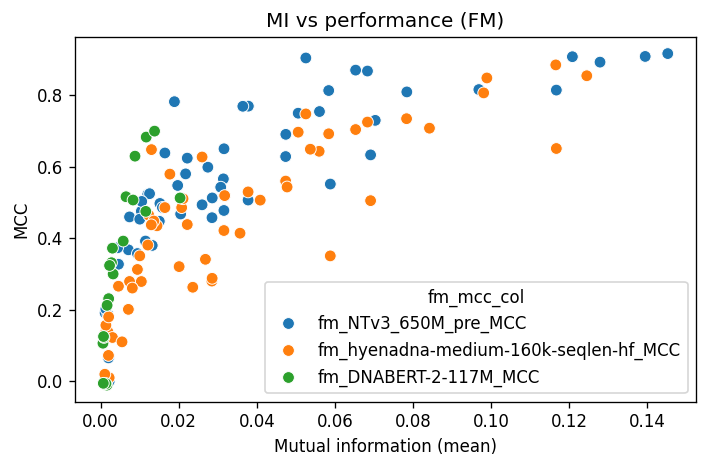

In [36]:
# Usa info_theory_embeddings.csv per MI e records.csv per MCC
mi = pd.read_csv('../results/info_theory_embeddings.csv')
mi = mi.rename(columns={'dataset': 'dataset'})

# long format per MI
mi_long = mi.melt(id_vars=['dataset'], var_name='mi_col', value_name='mi')
mi_long['mi'] = pd.to_numeric(mi_long['mi'], errors='coerce')

# mappa mi_col -> fm colonna MCC
fm_map = {
    'mi_fm_NTv3_650M_pre_mean': 'fm_NTv3_650M_pre_MCC',
    'mi_fm_hyenadna-medium-160k-seqlen-hf_mean': 'fm_hyenadna-medium-160k-seqlen-hf_MCC',
    'mi_fm_DNABERT-2-117M_mean': 'fm_DNABERT-2-117M_MCC',
}

mi_long = mi_long[mi_long['mi_col'].isin(fm_map.keys())].copy()
mi_long['fm_mcc_col'] = mi_long['mi_col'].map(fm_map)

perf = load_records()
perf = perf[[c for c in fm_map.values() if c in perf.columns]].apply(pd.to_numeric, errors='coerce')
perf = perf.reset_index().melt(id_vars=['dataset'], var_name='fm_mcc_col', value_name='mcc')

plot_df = mi_long.merge(perf, on=['dataset', 'fm_mcc_col'], how='inner')

plt.figure(figsize=(6, 4))
sns.scatterplot(data=plot_df, x='mi', y='mcc', hue='fm_mcc_col', s=50)
plt.xlabel('Mutual information (mean)')
plt.ylabel('MCC')
plt.title('MI vs performance (FM)')
plt.tight_layout()


## 10) Trade-off performance vs efficienza


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


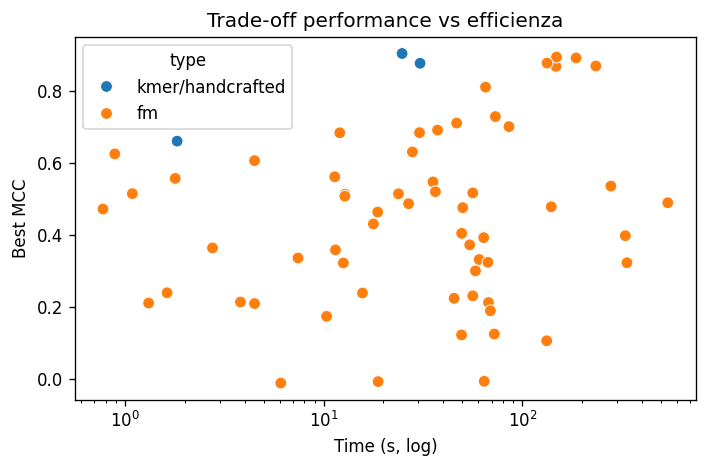

In [37]:
metric = 'MCC'

df = load_records()

best_k = best_kmer(df, metric)
best_f = best_fm(df, metric)

# tempo minimo per tipo

eff = pd.read_csv(EFF)

def method_type(m):
    m = m.lower()
    if m.startswith('kmer') or 'kmer' in m or m.startswith('wms') or m.startswith('qt') or m.startswith('wavelet'):
        return 'kmer/handcrafted'
    if m.startswith('fm_') or m.startswith('tok_'):
        return 'fm'
    return 'other'

eff['type'] = eff['method'].map(method_type)

min_time = eff.groupby(['dataset', 'type'])['time_sec'].min().reset_index()

perf_df = pd.DataFrame({
    'dataset': df.index.to_list(),
    'best_kmer': best_k.to_list(),
    'best_fm': best_f.to_list(),
})

# crea punti per kmer e fm
k_points = min_time[min_time['type'] == 'kmer/handcrafted'].merge(perf_df, on='dataset')
f_points = min_time[min_time['type'] == 'fm'].merge(perf_df, on='dataset')

k_points = k_points[['dataset', 'time_sec', 'best_kmer']].rename(columns={'best_kmer': 'perf'})
k_points = k_points.assign(type='kmer/handcrafted')

f_points = f_points[['dataset', 'time_sec', 'best_fm']].rename(columns={'best_fm': 'perf'})
f_points = f_points.assign(type='fm')

plot_df = pd.concat([k_points, f_points], ignore_index=True)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=plot_df, x='time_sec', y='perf', hue='type', s=50)
plt.xscale('log')
plt.xlabel('Time (s, log)')
plt.ylabel(f'Best {metric}')
plt.title('Trade-off performance vs efficienza')
plt.tight_layout()


## 11) Distribuzione lunghezza sequenza (seq_len_mean)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


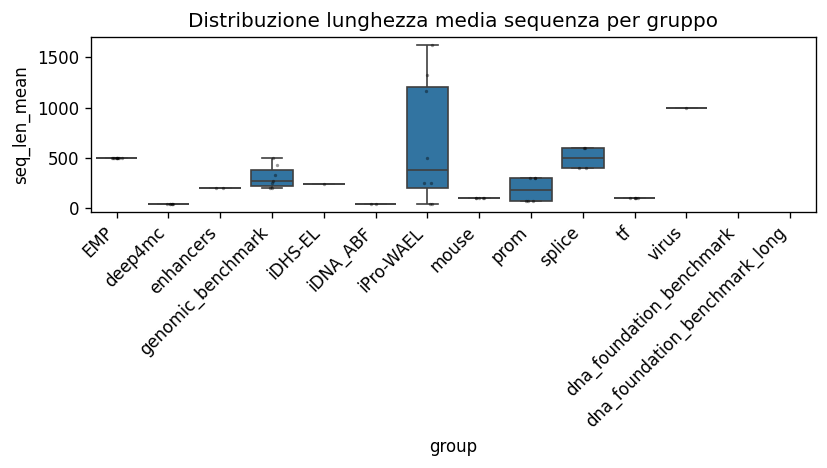

In [38]:
df = load_records()

plot_df = df[['group', 'seq_len_mean']].copy()
plot_df['seq_len_mean'] = pd.to_numeric(plot_df['seq_len_mean'], errors='coerce')

plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df, x='group', y='seq_len_mean')
sns.stripplot(data=plot_df, x='group', y='seq_len_mean', color='black', size=2, alpha=0.4)
plt.xticks(rotation=45, ha='right')
plt.title('Distribuzione lunghezza media sequenza per gruppo')
plt.tight_layout()
